# Tensor Stream 2D Demo

Demonstrates piecewise bicubic fitting and constructive polynomial TT evaluation using the `tensor_stream` package.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

from tensor_stream import fit_bicubic_to_image, reconstruct_image_from_coefficients
from tensor_stream.polynomial_tt import evaluate_polynomial, mps_eval, coordinates_from_bits

In [3]:
image = resize(data.camera(), (64, 64), anti_aliasing=True).astype(float) / 255.0

coeffs, sigmas = fit_bicubic_to_image(image, k=4)
reconstructed, _ = reconstruct_image_from_coefficients(coeffs)

print('num blocks:', len(coeffs), 'x', len(coeffs))
print('mean abs error:', np.mean(np.abs(reconstructed - image)))

num blocks: 16 x 16
mean abs error: 7.510647760748782e-18


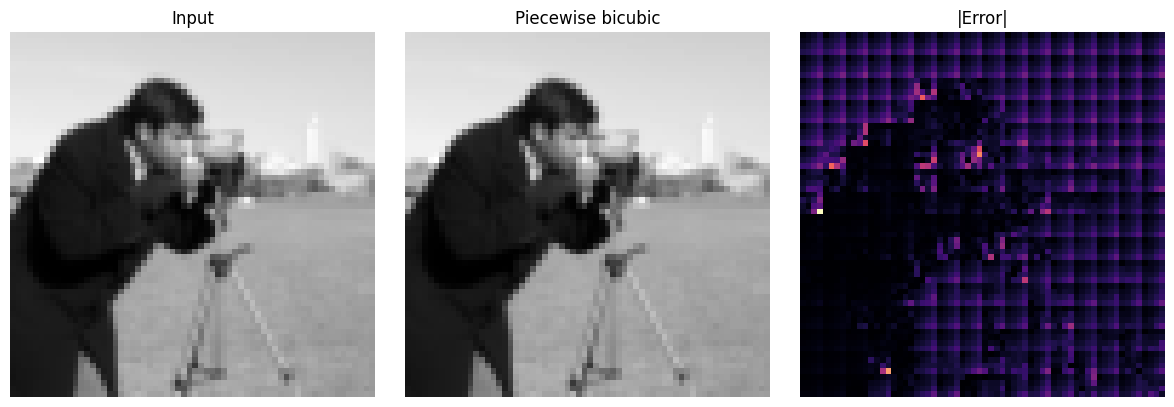

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(image, cmap='gray'); ax[0].set_title('Input')
ax[1].imshow(reconstructed, cmap='gray'); ax[1].set_title('Piecewise bicubic')
ax[2].imshow(np.abs(reconstructed - image), cmap='magma'); ax[2].set_title('|Error|')
for a in ax:
    a.axis('off')
plt.tight_layout()

In [5]:
coeff_poly = np.array([[1.0, 2.0, 0.0], [0.5, -1.0, 0.0], [0.0, 0.0, 0.25]])
x_bits = [1, 0, 1]
y_bits = [0, 1, 1]
x, y = coordinates_from_bits(x_bits, y_bits, 0.0, 1.0)

print('direct:', evaluate_polynomial(coeff_poly, x, y))
print('tt eval:', mps_eval(coeff_poly, x_bits, y_bits, 0.0, 1.0))

direct: 2.552894627238651
tt eval: 2.5528946272386506
